In [1]:
# 1. Introduction et Preoblematique Business
# Prediction du churn bancaire pour reduire les pertes de chiffre d'affaires et maximiser e ROI d'une campagne de retention
# 2. Chargement des donnees et préparation SQL
# Connexion SQLite, ingestion du CSV et requete SQL (CASE WHEN sur gender)
import pandas as pd
import sqlite3

df_bank = pd.read_csv("Bank Customer Churn Prediction.csv")

#creation de la base sqlite
conn = sqlite3.connect(":memory:")
df_bank.to_sql ("clients_banque", conn, if_exists="replace", index=False)

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  


10000

In [12]:
requete = """
SELECT
    credit_score,
    age,
    tenure,
    balance,
    products_number,
    CASE
     WHEN gender='Female' THEN 1
     ELSE 0
    END AS Genre,
    churn
FROM clients_banque;
"""
df_sql = pd.read_sql_query(requete, conn)
df_sql.head()

,credit_score,age,tenure,balance,products_number,Genre,churn
0,619,42,2,0.00,1,1,1
1,608,41,1,83807.86,1,1,0
2,502,42,8,159660.80,3,1,1
3,699,39,1,0.00,2,1,0
4,850,43,2,125510.82,1,1,0


In [18]:
#3. Modélisation Machine Learning
# Baseline avec Regression Logistique vs Modele avancé avec Random Forest

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#definition des variables explicatives X et cible y
X = df_sql[['credit_score','age','tenure','balance','products_number','Genre']]
y = df_sql['churn']

#separation des donnees en entrainement Train(80%) et test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y , train_size=0.8, random_state=42)

#entrainement du modele
modele_bank = LogisticRegression (max_iter=1000)
modele_bank.fit(X_train, y_train)

#prediction sur les donnees test
y_pred = modele_bank.predict(X_test)
print(classification_report(y_test, y_pred))
precision = accuracy_score(y_test, y_pred)
print("la precision du modele", precision)

              precision    recall  f1-score   support

           0       0.81      0.97      0.88      1607
           1       0.37      0.08      0.14       393

    accuracy                           0.79      2000
   macro avg       0.59      0.52      0.51      2000
weighted avg       0.72      0.79      0.74      2000

la precision du modele 0.792


In [22]:
cm = confusion_matrix(y_test, y_pred)
print("les vrais positifs", cm[1][1], "les faux positifs", cm[0][1])
print("les vrais negatifs", cm[0][0], "les faux negatifs", cm[1][0])

les vrais positifs 33 les faux positifs 56
les vrais negatifs 1551 les faux negatifs 360


In [27]:
#4. Evaluation et Analyse de la valeur Business (ROI)
# Matrice de confusion, rapoort de classification et clcul du gain net en euros 
total_client_cible = cm[1][1]+cm[0][1]
cout_campagne = 30*total_client_cible
client_sauve=int(0.4*cm[1][1])
CA_preserve = 300*client_sauve
gain_net=CA_preserve - cout_campagne
print('cout campagne', cout_campagne)
print('client sauvé', client_sauve)
print('chiffre perservé', CA_preserve)
print('gain net', gain_net)

cout campagne 2670
client sauvé 13
chiffre perservé 3900
gain net 1230


In [29]:
from sklearn.ensemble import RandomForestClassifier

#on instancie et entraine le modele 
rf_bank = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bank.fit(X_train, y_train)

#on predit sur X_test
y_pred_rf = rf_bank.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1607
           1       0.67      0.42      0.52       393

    accuracy                           0.85      2000
   macro avg       0.77      0.69      0.71      2000
weighted avg       0.83      0.85      0.83      2000



In [38]:
cm_rf=confusion_matrix(y_test, y_pred_rf)
print("les vrais positifs", cm_rf[1][1], "les faux positifs", cm_rf[0][1])
print("les vrais negatifs", cm_rf[0][0], "les faux negatifs", cm_rf[1][0])
client_cible = cm_rf[1][1]+cm_rf[0][1]
cout_campagne_rf = 30*client_cible
client_sauve_rf=int(0.4*cm_rf[1][1])
CA_preserve_rf = 300*client_sauve_rf
gain_net_rf=CA_preserve_rf - cout_campagne_rf
print('cout campagne', cout_campagne_rf)
print('client sauvé', client_sauve_rf)
print('chiffre perservé', CA_preserve_rf)
print('gain net', gain_net_rf)

les vrais positifs 167 les faux positifs 82
les vrais negatifs 1525 les faux negatifs 226
cout campagne 7470
client sauvé 66
chiffre perservé 19800
gain net 12330


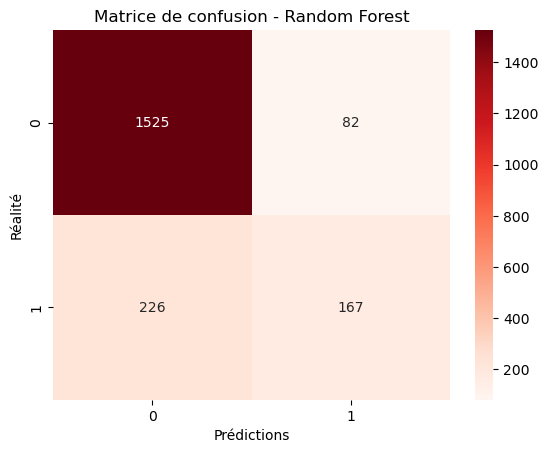

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds')
plt.title('Matrice de confusion - Random Forest')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.show()

In [ ]:
#5. Conclusion et recommandations
# Résumé des resultats et étapes futures (amelioration du Recall via SMOTE)

In [39]:
def calculer_roi_campagne(cm, cout_unitaire=30, valeur_client=300, taux_conversion=0.40):
    """
    Calcule l'impact financier d'un modèle de churn.
    """
    vrais_positifs = cm[1][1]
    faux_positifs = cm[0][1]
    
    clients_cibles = vrais_positifs + faux_positifs
    cout_total = clients_cibles * cout_unitaire
    
    clients_sauves = int(vrais_positifs * taux_conversion)
    ca_conserve = clients_sauves * valeur_client
    
    gain_net = ca_conserve - cout_total
    
    return {
        "Clients ciblés": clients_cibles,
        "Coût Campagne (€)": cout_total,
        "Clients sauvés": clients_sauves,
        "CA Préservé (€)": ca_conserve,
        "Gain Net (€)": gain_net
    }

# Test immédiat sur ton Random Forest :
res = calculer_roi_campagne(cm_rf)
for k, v in res.items():
    print(f"{k} : {v}")

Clients ciblés : 249
Coût Campagne (€) : 7470
Clients sauvés : 66
CA Préservé (€) : 19800
Gain Net (€) : 12330
